# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Jose Alberto Vargas Chavez"            # Tu nombre completo
MATRICULA = "81668"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "alcohol"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Jose Alberto Vargas Chavez
Matrícula: 81668
Dataset asignado: alcohol


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


/Users/josep/Documents/BigData/UI_2/.venv2/bin/python


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: alcohol
Descripcion: Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio (%)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,2.034725
1,Afghanistan,AFG,2001,2.032329
2,Afghanistan,AFG,2002,2.033833
3,Afghanistan,AFG,2003,2.034417
4,Afghanistan,AFG,2004,2.035337
5,Afghanistan,AFG,2005,2.034475
6,Afghanistan,AFG,2006,2.038559
7,Afghanistan,AFG,2007,2.029229
8,Afghanistan,AFG,2008,2.022360
9,Afghanistan,AFG,2009,2.018910


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(3929, 4)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3929 non-null   str    
 1   code    3929 non-null   str    
 2   year    3929 non-null   int64  
 3   valor   3929 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 122.9 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3929.000000
mean       42.460783
std        24.126328
min         0.830784
25%        24.925045
50%        42.829540
75%        62.844517
max        85.056270
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

In [10]:
print("Año inicial:", df["year"].min())
print("Año final:", df["year"].max())

Año inicial: 2000
Año final: 2020


**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*El dataset contiene 3,929 registros y no presenta valores nulos en ninguna de sus columnas. Los datos abarcan de 2000 a 2020 y la variable valor es cuantitativa continua, ya que representa el porcentaje de adultos que consumieron alcohol durante el último año.*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [11]:
# Pregunta 1
# Tu codigo aqui

# Filtrar únicamente países reales
df_paises = df[df[config["filtro_paises"]].notnull()]

# Cantidad de países distintos
cantidad_paises = df_paises["entity"].nunique()
print("Cantidad de países distintos:", cantidad_paises)

# Diez registros con mayor valor
top_10 = df_paises.nlargest(10, "valor")[["entity", "year", "valor"]]
print("\n10 países con mayor valor:")
print(top_10)

# Diez registros con menor valor
bottom_10 = df_paises.nsmallest(10, "valor")[["entity", "year", "valor"]]
print("\n10 países con menor valor:")
print(bottom_10)





Cantidad de países distintos: 189

10 países con mayor valor:
          entity  year      valor
69       Andorra  2006  85.056270
68       Andorra  2005  84.885210
70       Andorra  2007  84.741150
64       Andorra  2001  84.728065
67       Andorra  2004  84.604740
2117  Luxembourg  2017  84.553620
2119  Luxembourg  2019  84.505740
2118  Luxembourg  2018  84.496760
2116  Luxembourg  2016  84.465840
66       Andorra  2003  84.429360

10 países con menor valor:
       entity  year     valor
1931   Kuwait  2020  0.830784
1927   Kuwait  2016  0.859087
779   Comoros  2002  0.868431
778   Comoros  2001  0.871331
777   Comoros  2000  0.872753
784   Comoros  2007  0.886865
785   Comoros  2008  0.887536
1926   Kuwait  2015  0.893008
787   Comoros  2010  0.895492
788   Comoros  2011  0.896825


**Interpretación:**

*Los paises europeos obtienen mayor valor y los africanos el menor, por lo que los europeos son mas alcoholicos que los africanos, pero tambien podria ser por la escazes de recursos en africa o la cultura.*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [12]:
# Pregunta 2
# Tu codigo aqui

datos_pais1 = df_paises[df_paises["entity"] == "Mexico"]
datos_pais2 = df_paises[df_paises["entity"] == "United States"]

anio_inicial = max(datos_pais1["year"].min(), datos_pais2["year"].min())
anio_final = min(datos_pais1["year"].max(), datos_pais2["year"].max())

comparacion = df_paises[
    (df_paises["entity"].isin(["Mexico", "United States"])) &
    (df_paises["year"] >= anio_inicial) &
    (df_paises["year"] <= anio_final)
]


print("Rango común de años:", anio_inicial, "-", anio_final)
comparacion

Rango común de años: 2000 - 2020


,entity,code,year,valor
2289,Mexico,MEX,2000,43.696823
2290,Mexico,MEX,2001,43.486710
2291,Mexico,MEX,2002,43.310062
2292,Mexico,MEX,2003,43.456112
2293,Mexico,MEX,2004,43.573890
2294,Mexico,MEX,2005,43.666603
2295,Mexico,MEX,2006,44.073420
2296,Mexico,MEX,2007,42.525486
2297,Mexico,MEX,2008,42.630943
2298,Mexico,MEX,2009,42.772570


**Interpretación:**

*Los estadounidenses han sido siempre mas alcoholicos que los mexicanos en el rango 2000 - 2020*

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [13]:
# Pregunta 3
# Tu codigo aqui

paises =["Mexico", "France", "China", "Australia", "South Africa"]

datos_paises = df_paises[df_paises["entity"].isin(paises)]

anio_reciente = datos_paises["year"].max()
print("Año más reciente en los países seleccionados:", anio_reciente)

comparacion = datos_paises[datos_paises["year"] == anio_reciente][["entity", "year", "valor"]]

pais_maxValue = comparacion.loc[comparacion["valor"].idxmax()]
print("País con mayor valor en el año más reciente:")
print(pais_maxValue)
pais_minValue = comparacion.loc[comparacion["valor"].idxmin()]
print("País con menor valor en el año más reciente:")
print(pais_minValue)
diferencia = pais_maxValue["valor"] - pais_minValue["valor"]
print("Diferencia entre el país con mayor y menor valor:", diferencia)

Año más reciente en los países seleccionados: 2020
País con mayor valor en el año más reciente:
entity    Australia
year           2020
valor      80.67013
Name: 188, dtype: object
País con menor valor en el año más reciente:
entity    South Africa
year              2020
valor        29.618544
Name: 3277, dtype: object
Diferencia entre el país con mayor y menor valor: 51.051586


**Interpretación:**

*El acohol sigue siendo muy poco consumido en africa que en cualquier otro continente, debido a que son 5 paises analizados de diferente continente y el min lo consigue sudafrica. La diferencia es de casi el triple*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [14]:
# Pregunta 4
# Tu codigo aqui

GrupoLatam = ["Mexico", "Colombia", "Argentina"]
GrupoAsia = ["China", "Vietnam", "Japan"]

datos_2020 = df_paises[df_paises["year"] == 2020]

promedio_latam = datos_2020[datos_2020["entity"].isin(GrupoLatam)]["valor"].mean()
promedio_asia = datos_2020[datos_2020["entity"].isin(GrupoAsia)]["valor"].mean()


print("Promedio de valor en 2020 para Latinoamérica:", promedio_latam)
print("Promedio de valor en 2020 para Asia:", promedio_asia)

Promedio de valor en 2020 para Latinoamérica: 51.310592333333325
Promedio de valor en 2020 para Asia: 60.489477666666666


**Interpretación:**

*Latinoamerica es menos alcoholica que los asiaticos por una pequeña diferencia.*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [15]:
mexico = (
    df_paises[
        (df_paises["entity"] == "Mexico") &
        (df_paises["year"].between(2000, 2020))
    ]
    .sort_values("year")
)

fila_maximo = mexico.loc[mexico["valor"].idxmax()]
fila_minimo = mexico.loc[mexico["valor"].idxmin()]

if mexico["valor"].is_monotonic_increasing:
    tendencia = "creciente"
elif mexico["valor"].is_monotonic_decreasing:
    tendencia = "decreciente"
else:
    tendencia = "fluctuante"

print(mexico[["year", "valor"]])
print("\nAño con valor máximo:", int(fila_maximo["year"]))
print("Valor máximo:", fila_maximo["valor"])
print("Año con valor mínimo:", int(fila_minimo["year"]))
print("Valor mínimo:", fila_minimo["valor"])
print("Tendencia general:", tendencia)

      year      valor
2289  2000  43.696823
2290  2001  43.486710
2291  2002  43.310062
2292  2003  43.456112
2293  2004  43.573890
2294  2005  43.666603
2295  2006  44.073420
2296  2007  42.525486
2297  2008  42.630943
2298  2009  42.772570
2299  2010  42.275200
2300  2011  42.341488
2301  2012  42.171944
2302  2013  41.940746
2303  2014  42.286865
2304  2015  42.922820
2305  2016  43.080498
2306  2017  43.575916
2307  2018  43.875687
2308  2019  43.971450
2309  2020  42.036960

Año con valor máximo: 2006
Valor máximo: 44.07342
Año con valor mínimo: 2013
Valor mínimo: 41.940746
Tendencia general: fluctuante


**Interpretación:**

*El consumo en mexico se ha mantenido estable y no tiene una tendencia clara, por lo que creo que es fluctuante *

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [16]:
# Pregunta 6
# Tu codigo aqui

mexico = df_paises[df_paises["entity"] == "Mexico"].sort_values("year")

primer_anio = mexico.iloc[0]
ultimo_anio = mexico.iloc[-1]

cambio_porcentual = (
    (ultimo_anio["valor"] - primer_anio["valor"])
    / primer_anio["valor"]
) * 100

print("Primer año:", int(primer_anio["year"]))
print("Valor inicial:", primer_anio["valor"])
print("Último año:", int(ultimo_anio["year"]))
print("Valor final:", ultimo_anio["valor"])
print("Cambio porcentual:", cambio_porcentual, "%")

Primer año: 2000
Valor inicial: 43.696823
Último año: 2020
Valor final: 42.03696
Cambio porcentual: -3.798589659481655 %


**Interpretación:**

*Ha ido cayendo el consumo en base a nuevas leyes de importación comercial, ademas de control del consumo en el pais y impuestos.*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [17]:
# Pregunta 7
# Tu codigo aqui

valores = df_paises.loc[
    df_paises["year"] == 2020, "valor"
].dropna().to_numpy()

media = np.mean(valores)
mediana = np.median(valores)
desviacion_estandar = np.std(valores)

print("Año más reciente:", anio_reciente)
print("Media:", media)
print("Mediana:", mediana)
print("Desviación estándar:", desviacion_estandar)

Año más reciente: 2020
Media: 42.25048457647059
Mediana: 42.03696
Desviación estándar: 23.997187046049685


**Interpretación:**

*El consumo de alcholo es un habito comun en la mayoria de paises ya que la desviacion estandar no esta siendo tan alta.*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

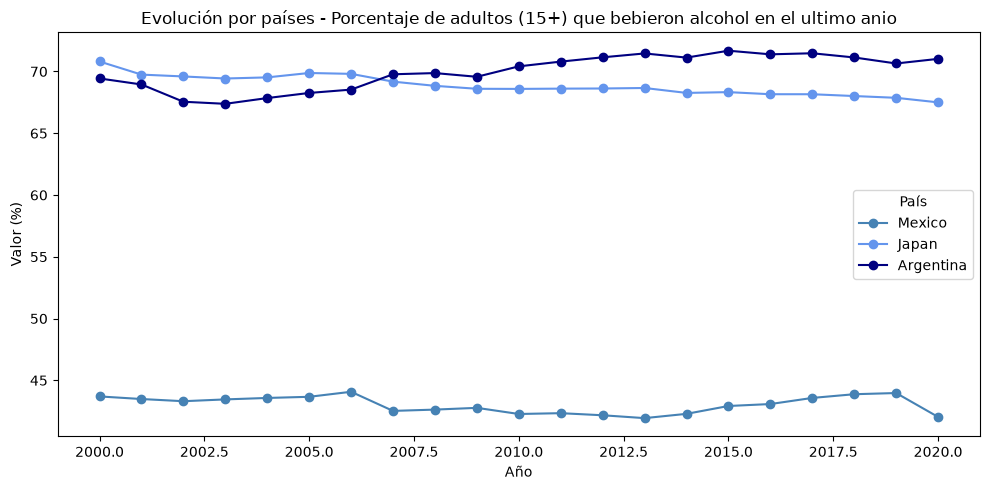

In [18]:
# Pregunta 8
# Tu codigo aqui

df_paises = df[df[config["filtro_paises"]].notnull()]

paises_consultados = ["Mexico", "Japan", "Argentina"]
colores = ["steelblue", "cornflowerblue", "navy"]

# Gráfica de líneas

plt.figure(figsize=(10, 5))

for pais, color in zip(paises_consultados, colores):
    datos_pais = (
        df_paises[df_paises["entity"] == pais]
        .sort_values("year")
    )

    plt.plot(
        datos_pais["year"],
        datos_pais["valor"],
        color=color,
        marker="o",
        label=pais
    )

plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.title(f"Evolución por países - {config['descripcion']}")

plt.legend(title="País")
plt.tight_layout()
plt.show()


**Interpretación:**

*Entre 2000 y 2006, Japón presentó el porcentaje más alto de los tres países, pero a partir de 2007 Argentina lo superó y mantuvo una tendencia general creciente. Japón mostró una disminución gradual, mientras que México permaneció con los valores más bajos y presentó pequeñas fluctuaciones durante todo el periodo.*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

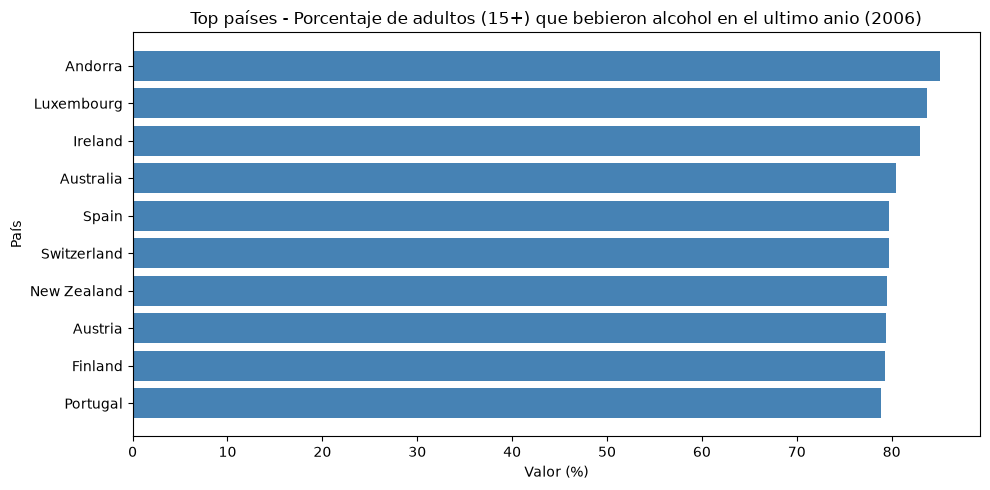

In [19]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2006

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()


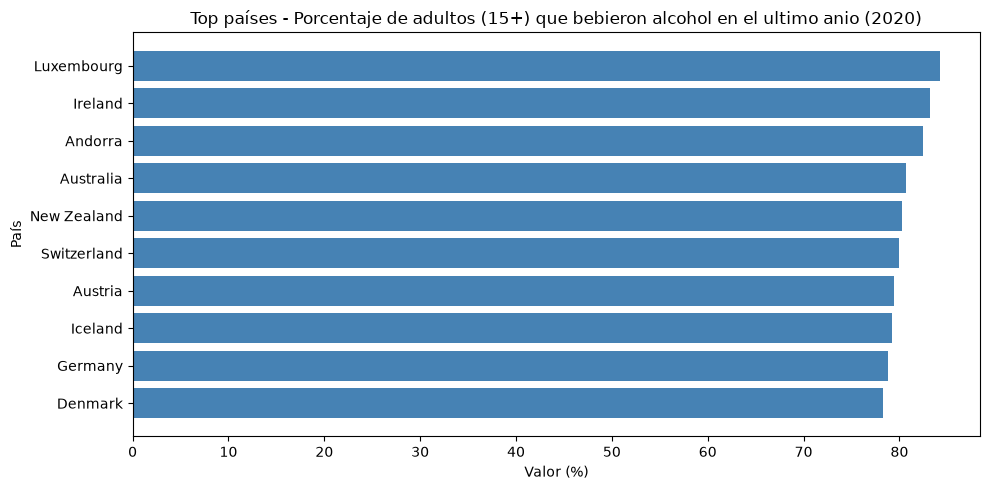

In [20]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2020

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()


**Interpretación:**

*Entre 2006 y 2020, el Top 10 presentó algunos cambios: Luxemburgo subió al primer lugar, mientras Andorra bajó del primero al tercero. España, Finlandia y Portugal salieron del ranking y fueron reemplazados por Islandia, Alemania y Dinamarca; aun así, los porcentajes se mantuvieron altos y relativamente estables.*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*El dataset permitió analizar el porcentaje de adultos que consumieron alcohol entre 2000 y 2020.
Se observaron diferencias importantes entre países, aunque los primeros lugares del ranking fueron relativamente estables.
México mantuvo valores cercanos al 42–44 %, mientras Japón disminuyó y Argentina mostró una tendencia general creciente.
Los datos no presentan valores nulos y el indicador está expresado como porcentaje estandarizado por edad, lo que facilita la comparación.
Sin embargo, el indicador solo muestra si una persona consumió alcohol durante el último año, sin medir la cantidad ni la frecuencia.
Además, la información termina en 2020 y los promedios nacionales pueden ocultar diferencias entre regiones o grupos sociales.
Con más tiempo, compararía regiones y relacionaría el consumo con factores económicos, culturales y de salud.*

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
